Hybrid Quantum GAN where both Generator and Discriminator have VQC embedded within classical NN training on the Quark and Gluon dataset. I started with 4 qubits, then implemented 8 qubits. Still need to tunned the hyperparameters by first defining a better evaluation metric.


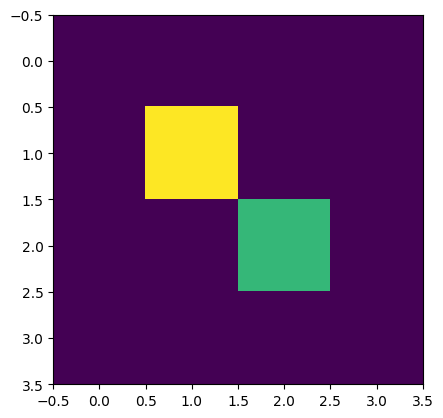

In [16]:
hep_imgs = np.load("hep_train_images.npy") 
plt.imshow(hep_imgs[0])

Epoch  1 | D-loss: 0.6141 | G-loss: 0.8847
Epoch  2 | D-loss: 0.5346 | G-loss: 0.9586
Epoch  3 | D-loss: 0.4976 | G-loss: 0.9918
Epoch  4 | D-loss: 0.4672 | G-loss: 1.0231
Epoch  5 | D-loss: 0.4160 | G-loss: 1.0942
Epoch  6 | D-loss: 0.4322 | G-loss: 1.0947
Epoch  7 | D-loss: 0.4138 | G-loss: 1.1283
Epoch  8 | D-loss: 0.3968 | G-loss: 1.1759
Epoch  9 | D-loss: 0.3857 | G-loss: 1.2039
Epoch 10 | D-loss: 0.3732 | G-loss: 1.2550
Epoch 11 | D-loss: 0.3627 | G-loss: 1.2948
Epoch 12 | D-loss: 0.3571 | G-loss: 1.3565
Epoch 13 | D-loss: 0.3394 | G-loss: 1.3999
Epoch 14 | D-loss: 0.3289 | G-loss: 1.4263
Epoch 15 | D-loss: 0.3240 | G-loss: 1.4812
Epoch 16 | D-loss: 0.3201 | G-loss: 1.5209
Epoch 17 | D-loss: 0.3068 | G-loss: 1.5358
Epoch 18 | D-loss: 0.2950 | G-loss: 1.5852
Epoch 19 | D-loss: 0.2936 | G-loss: 1.6679
Epoch 20 | D-loss: 0.2875 | G-loss: 1.6935
Epoch 21 | D-loss: 0.2881 | G-loss: 1.7345
Epoch 22 | D-loss: 0.2795 | G-loss: 1.7642
Epoch 23 | D-loss: 0.2734 | G-loss: 1.8357
Epoch 24 | 

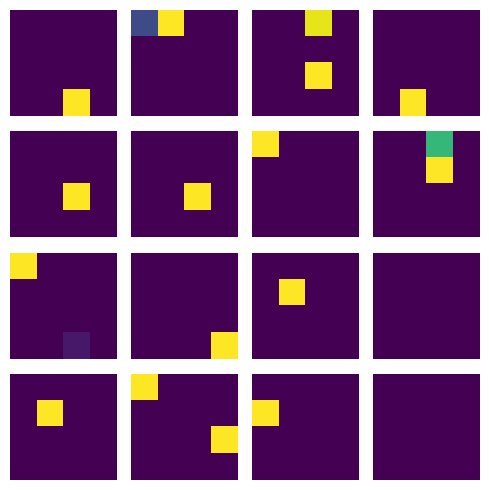

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pennylane as qml
from pennylane.qnn import TorchLayer
import matplotlib.pyplot as plt

batch_size = 128
latent_dim = 100
n_qubits   = 4
q_depth    = 3
lr         = 1e-4
n_epochs   = 30
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hep_imgs = np.load("hep_train_images.npy")    # shape [N, H, W], float in [0,1]
hep_imgs = (hep_imgs * 2.0) - 1.0             # rescale → [–1,1]
hep_imgs = hep_imgs[:, None, :, :]            # add channel dim → [N,1,H,W]
hep_tensor = torch.from_numpy(hep_imgs).float()

train_loader = DataLoader(
    TensorDataset(hep_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.init_size = img_size // 4         
        self.fc = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, n_qubits)
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        b = z.size(0)
        x = self.fc(z).view(b, 128, self.init_size, self.init_size)
        feat   = x.mean(dim=[2,3])                    # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out  = quantum_layer(angles)                # [b,n_qubits]
        fusion = self.post_q(q_out).view(b,128,1,1)
        x = x * (1 + fusion)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
        )
        feat_dim = 32 * (img_size // 4) * (img_size // 4)
        self.fc1   = nn.Linear(feat_dim, 128)
        self.pre_q = nn.Linear(128, n_qubits)
        self.post_q= nn.Linear(n_qubits, 1)

    def forward(self, img):
        b = img.size(0)
        x = self.down(img)
        feat   = torch.relu(self.fc1(x))
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out  = quantum_layer(angles)
        return torch.sigmoid(self.post_q(q_out))


_, _, H, W = hep_tensor.shape
assert H == W, "expect square images"
img_size = H

G = Generator(img_size).to(device)
D = Discriminator(img_size).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()


for epoch in range(1, n_epochs+1):
    g_loss_acc = 0.0
    d_loss_acc = 0.0

    for (real_imgs,) in train_loader:
        real = real_imgs.to(device)
        b = real.size(0)
        ones  = torch.ones(b,1, device=device)
        zeros = torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        d_real   = D(real)
        loss_real= criterion(d_real, ones)
        z        = torch.randn(b, latent_dim, device=device)
        d_fake   = D(G(z).detach())
        loss_fake= criterion(d_fake, zeros)
        d_loss   = 0.5*(loss_real + loss_fake)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        z        = torch.randn(b, latent_dim, device=device)
        g_loss   = criterion(D(G(z)), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="viridis")
    ax.axis("off")
plt.tight_layout()
plt.show()


Now use 8 qubits. 8 qubit GAN takes a very long time to train on this large dataset. 

Epoch  1 | D-loss: 0.6934 | G-loss: 0.6983
Epoch  2 | D-loss: 0.6901 | G-loss: 0.6959
Epoch  3 | D-loss: 0.6870 | G-loss: 0.6994
Epoch  4 | D-loss: 0.6839 | G-loss: 0.7029
Epoch  5 | D-loss: 0.6808 | G-loss: 0.7064
Epoch  6 | D-loss: 0.6779 | G-loss: 0.7099
Epoch  7 | D-loss: 0.6750 | G-loss: 0.7136
Epoch  8 | D-loss: 0.6722 | G-loss: 0.7172
Epoch  9 | D-loss: 0.6695 | G-loss: 0.7212
Epoch 10 | D-loss: 0.6667 | G-loss: 0.7249


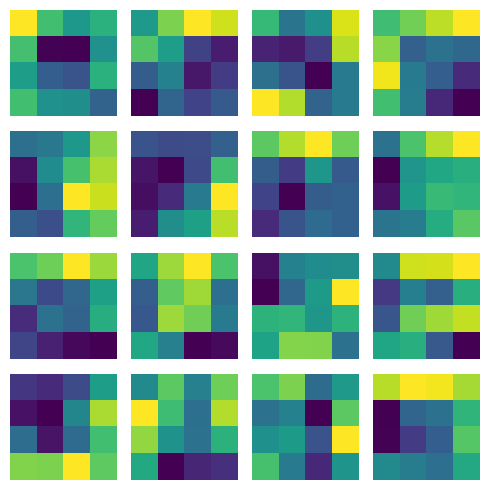

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt


batch_size = 128
latent_dim = 100
n_qubits   = 8     
q_depth    = 3
lr         = 1e-4
n_epochs   = 10
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hep_imgs = np.load("hep_train_images.npy")        # [N,H,W]
hep_imgs = hep_imgs * 2 - 1                       # → [-1,1]
hep_imgs = hep_imgs[:, None, :, :]                # → [N,1,H,W]
hep_tensor = torch.from_numpy(hep_imgs).float()

train_loader = DataLoader(
    TensorDataset(hep_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(angles, weights):
    # RX/RY encoding
    for i in range(n_qubits):
        qml.RX(angles[i], wires=i)
        qml.RY(angles[i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

class Generator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.init_size = img_size // 4
        self.fc    = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q = nn.Linear(128, 2 * n_qubits)
        self.q_weights = nn.Parameter(torch.randn(q_depth, n_qubits))
        self.post_q= nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        b = z.size(0)
        x = self.fc(z).view(b, 128, self.init_size, self.init_size)
        feat   = x.mean(dim=[2,3])                         # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi   # [b,2*n_qubits]

        qouts = []
        for a in angles:
            out_list = qcircuit(a.to('cpu'), self.q_weights.to('cpu'))
            out_tensor = torch.tensor(out_list, dtype=torch.float32, device=device)
            qouts.append(out_tensor)
        q_out = torch.stack(qouts, dim=0)                  # [b,n_qubits]

        fusion = self.post_q(q_out).view(b,128,1,1)
        x = x * (1 + fusion)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
        )
        feat_dim = 32 * (img_size // 4) * (img_size // 4)
        self.fc1   = nn.Linear(feat_dim, 128)
        self.pre_q = nn.Linear(128, 2 * n_qubits)
        self.q_weights = nn.Parameter(torch.randn(q_depth, n_qubits))
        self.post_q= nn.Linear(n_qubits, 1)

    def forward(self, img):
        b = img.size(0)
        x = self.down(img)
        feat   = torch.relu(self.fc1(x))                   # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi   # [b,2*n_qubits]

        qouts = []
        for a in angles:
            out_list   = qcircuit(a.to('cpu'), self.q_weights.to('cpu'))
            out_tensor = torch.tensor(out_list, dtype=torch.float32, device=device)
            qouts.append(out_tensor)
        q_out = torch.stack(qouts, dim=0)                  # [b,n_qubits]

        return torch.sigmoid(self.post_q(q_out))

_, _, H, W = hep_tensor.shape
img_size = H
G = Generator(img_size).to(device)
D = Discriminator(img_size).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc = d_loss_acc = 0.0
    for (real_imgs,) in train_loader:
        real = real_imgs.to(device)
        b = real.size(0)
        ones  = torch.ones(b,1, device=device)
        zeros = torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        d_real   = D(real)
        loss_r   = criterion(d_real, ones)
        z        = torch.randn(b, latent_dim, device=device)
        d_fake   = D(G(z).detach())
        loss_f   = criterion(d_fake, zeros)
        d_loss   = 0.5 * (loss_r + loss_f)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        z2       = torch.randn(b, latent_dim, device=device)
        g_loss   = criterion(D(G(z2)), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="viridis")
    ax.axis("off")
plt.tight_layout()
plt.show()


Very different result, will evaluate later. 